# 05 · One-to-Many — Generating Sequences with an Autoregressive RNN

So far our RNNs **consumed** sequences and produced a single answer (many-to-one). Now we flip the
arrow: from a small seed we **produce a whole sequence**, one element at a time. This is the
**one-to-many / generative** pattern behind text generation, music generation, and — the modern
descendant — the language models you use every day (which are Transformers, but share this exact
*autoregressive* generation idea).

We'll build a **character-level name generator**: train an LSTM on a list of real names, then let
it invent **new, plausible-sounding names**. It's small, fast, and the results are fun and easy to
judge by eye.

You'll learn:
1. How to turn text into integer tokens with a **vocabulary**.
2. The subtle but crucial point: we **train** the model as *many-to-many* (predict the next
   character at every position), but we **use** it as *one-to-many* (feed its own output back in).
3. **Embeddings** — a learned lookup table that replaces clumsy one-hot vectors.
4. **Sampling** and the **temperature** knob that controls creativity vs. safety.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. The data: a list of names

We embed a corpus of names directly so the notebook is fully self-contained (no downloads). The
model will learn the *statistics of letter sequences* in these names — which letters tend to
start a name, common endings like "-ia" or "-on", plausible consonant/vowel patterns — and use
that to generate new ones.

In [2]:
names = [
    "amelia","oliver","sophia","liam","emma","noah","ava","william","isabella","james",
    "mia","benjamin","charlotte","lucas","amara","henry","evelyn","alexander","harper","daniel",
    "elena","gabriel","aurora","samuel","luna","david","chloe","joseph","layla","matthew",
    "penelope","julian","nora","leo","hazel","adrian","violet","aaron","stella","nathan",
    "maria","antonio","lucia","marco","sofia","diego","valentina","mateo","camila","sebastian",
    "isabel","andres","carmen","pablo","elsa","victor","adriana","emilio","natalia","hugo",
    "olivia","ethan","abigail","jacob","emily","michael","elizabeth","daniel","grace","logan",
    "clara","ivan","laura","oscar","paula","ruben","teresa","alvaro","irene","javier",
    "rosa","felix","alba","bruno","noa","alma","dario","vera","enzo","nadia",
    "ana","luis","marta","jorge","sara","raul","elisa","cesar","julia","angel",
]
names = sorted(set(names))
print(f"{len(names)} names, e.g.:", names[:8])

# --- build the vocabulary (character <-> integer) ---
# We add two SPECIAL tokens:  '.' marks the END of a name (so the model learns when to stop),
# and it doubles as the START token we feed to kick off generation.
chars = ["."] + sorted(set("".join(names)))
stoi = {c: i for i, c in enumerate(chars)}   # string -> index
itos = {i: c for c, i in stoi.items()}       # index  -> string
VOCAB = len(chars)
print("vocabulary size:", VOCAB)
print("char->index map:", stoi)

99 names, e.g.: ['aaron', 'abigail', 'adrian', 'adriana', 'alba', 'alexander', 'alma', 'alvaro']
vocabulary size: 25
char->index map: {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'r': 16, 's': 17, 't': 18, 'u': 19, 'v': 20, 'w': 21, 'x': 22, 'y': 23, 'z': 24}


## 2. Turning names into training pairs

Key idea — **next-character prediction.** For the name `ana`, we frame it as: given what we've
seen so far, predict the next character. We wrap each name with the special `.` token at both ends:

```
input :  .  a  n  a
target:  a  n  a  .
```

So at every position the target is simply the **input shifted left by one**. Training the model to
predict the next character at *every* position is a **many-to-many (aligned)** setup — and it's
far more efficient than predicting only the final character, because every position contributes a
learning signal.

In [3]:
def encode_name(name):
    '''Return (input_ids, target_ids) for one name, using '.' as start & end marker.'''
    tokens = [stoi["."]] + [stoi[c] for c in name] + [stoi["."]]
    x = tokens[:-1]     # everything except the last  -> inputs
    y = tokens[1:]      # everything except the first -> targets (shifted by one)
    return x, y

xi, yi = encode_name("ana")
print("name 'ana' becomes:")
print("  input tokens :", xi, "->", [itos[i] for i in xi])
print("  target tokens:", yi, "->", [itos[i] for i in yi])
print("\nAt each step the model must predict the NEXT character (the target).")

# Because names have different lengths, we PAD each sequence to the longest, and remember the
# real length so padding doesn't pollute the loss.
encoded = [encode_name(n) for n in names]
maxlen = max(len(x) for x, _ in encoded)

X = torch.full((len(names), maxlen), stoi["."], dtype=torch.long)
Y = torch.full((len(names), maxlen), stoi["."], dtype=torch.long)
lengths = []
for i, (x, y) in enumerate(encoded):
    X[i, :len(x)] = torch.tensor(x)
    Y[i, :len(y)] = torch.tensor(y)
    lengths.append(len(x))
lengths = torch.tensor(lengths)
print("\nX shape (names, maxlen):", tuple(X.shape))

name 'ana' becomes:
  input tokens : [0, 1, 13, 1] -> ['.', 'a', 'n', 'a']
  target tokens: [1, 13, 1, 0] -> ['a', 'n', 'a', '.']

At each step the model must predict the NEXT character (the target).

X shape (names, maxlen): (99, 10)


## 3. Embeddings: a better way to feed characters

A character is a *category*, not a number — "c" (index 3) isn't "three times" the start token.
Two ways to feed categories to a network:

- **One-hot vectors** — a length-`VOCAB` vector of zeros with a single 1. Wasteful and carries no
  notion of similarity between characters.
- **Embeddings** *(what we use)* — a small **learned lookup table** mapping each character id to a
  dense vector (say 16 numbers). During training the model arranges this table so that characters
  used in similar contexts end up with similar vectors. `nn.Embedding` does exactly this.

Embeddings are the standard first layer for *any* categorical/token input — words, product ids,
user ids — so this pattern generalizes far beyond names.

In [4]:
class CharGenerator(nn.Module):
    def __init__(self, vocab, embed_dim=16, hidden=128, n_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab, embed_dim)      # id -> dense vector (learned)
        self.lstm  = nn.LSTM(embed_dim, hidden, num_layers=n_layers, batch_first=True)
        self.head  = nn.Linear(hidden, vocab)            # hidden -> score for each next char

    def forward(self, x, hidden=None):
        # x: (batch, time) integer token ids
        e = self.embed(x)                                # (batch, time, embed_dim)
        out, hidden = self.lstm(e, hidden)               # (batch, time, hidden)
        logits = self.head(out)                          # (batch, time, vocab): a prediction PER step
        return logits, hidden

model = CharGenerator(VOCAB).to(device)
print(model)
print("\nparameters:", sum(p.numel() for p in model.parameters()))

CharGenerator(
  (embed): Embedding(25, 16)
  (lstm): LSTM(16, 128, num_layers=2, batch_first=True)
  (head): Linear(in_features=128, out_features=25, bias=True)
)

parameters: 210473


## 4. Train the generator

The loss is **cross-entropy** between the predicted next-character distribution and the true next
character, **summed over every position** of every name. We use a mask so the padding positions
don't count. This is quick — a couple hundred passes over ~90 names.

epoch  80 | loss 1.013


epoch 160 | loss 0.721


epoch 240 | loss 0.717


epoch 320 | loss 0.716


epoch 400 | loss 0.715


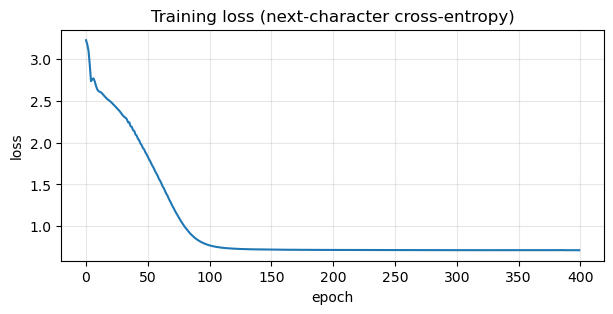

In [5]:
X, Y, lengths = X.to(device), Y.to(device), lengths.to(device)
opt = torch.optim.Adam(model.parameters(), lr=5e-3)

# build a mask that is True for REAL positions and False for padding
mask = torch.arange(maxlen, device=device)[None, :] < lengths[:, None]   # (names, maxlen)

losses = []
EPOCHS = 400
for epoch in range(EPOCHS):
    model.train()
    opt.zero_grad()
    logits, _ = model(X)                                   # (N, maxlen, VOCAB)
    # cross-entropy expects (N*maxlen, VOCAB) vs (N*maxlen,)
    loss_per_pos = F.cross_entropy(
        logits.reshape(-1, VOCAB), Y.reshape(-1), reduction="none"
    ).reshape(Y.shape)
    loss = (loss_per_pos * mask).sum() / mask.sum()        # average over REAL positions only
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if (epoch + 1) % 80 == 0:
        print(f"epoch {epoch+1:3d} | loss {loss.item():.3f}")

plt.figure(figsize=(7, 3))
plt.plot(losses); plt.title("Training loss (next-character cross-entropy)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(alpha=0.3); plt.show()

## 5. Generation = feed the model its own output (autoregression)

Here's the **one-to-many** part. To generate a name:

1. Start with the seed token `.` and an empty memory.
2. The model outputs a probability distribution over the next character.
3. **Sample** a character from that distribution.
4. **Feed that character back in** as the next input, keeping the hidden state.
5. Repeat until the model emits the end token `.`.

Because each new input is the model's *own previous output*, one seed unrolls into a whole
sequence — that feedback is exactly what "autoregressive" means.

### The temperature knob

Instead of always taking the single most-likely character (which produces repetitive, boring
output), we **sample**. **Temperature** `τ` reshapes the distribution before sampling:

- `τ → 0`: nearly always pick the top choice → *safe, repetitive, conservative.*
- `τ = 1`: sample from the model's raw probabilities → *balanced.*
- `τ > 1`: flatten the distribution → *more random, creative, but more typos.*

This single knob is the same "creativity/temperature" setting exposed by modern LLM APIs.

In [6]:
@torch.no_grad()
def generate(model, temperature=1.0, max_len=20):
    '''Generate one name by autoregressive sampling.'''
    model.eval()
    idx = torch.tensor([[stoi["."]]], device=device)   # start with the '.' token, shape (1,1)
    hidden = None
    out_chars = []
    for _ in range(max_len):
        logits, hidden = model(idx, hidden)            # feed ONE char, carry memory forward
        logits = logits[0, -1] / temperature           # last step's scores, temperature-scaled
        probs = F.softmax(logits, dim=-1)              # -> a probability distribution
        nxt = torch.multinomial(probs, num_samples=1)  # SAMPLE (not argmax) -> variety
        if nxt.item() == stoi["."]:                    # end token -> stop
            break
        out_chars.append(itos[nxt.item()])
        idx = nxt.view(1, 1)                            # the sampled char becomes the next input
    return "".join(out_chars)

print("Generated names at different temperatures:\n")
for temp in [0.5, 0.8, 1.0, 1.3]:
    sample = [generate(model, temperature=temp).capitalize() for _ in range(8)]
    print(f"  temperature {temp}:  {', '.join(sample)}")

Generated names at different temperatures:



  temperature 0.5:  Violet, Aurora, Alma, Ana, Lucia, Marta, Layla, Daniel
  temperature 0.8:  Hazel, Alexander, Lucia, Natalia, Harper, Harper, Alexander, Sophia
  temperature 1.0:  Daniel, Amelia, Oliver, Bruno, Elizabeth, Natalia, Angel, Ana


  temperature 1.3:  Aurora, Natalia, Isabella, Raul, Jostep, Michael, Sofia, Ethan


Notice the trend: **low temperature** gives safe, name-like (sometimes repetitive) outputs that
lean on the most common patterns; **high temperature** gets more adventurous and occasionally
produces unpronounceable strings. Some generated names will accidentally match the training set —
that's expected with such a tiny corpus.

Let's quantify how many generated names are **new** (not in the training list) vs. memorized.

In [7]:
train_set = set(names)
generated = [generate(model, temperature=1.0) for _ in range(200)]
novel = [g for g in generated if g and g not in train_set]
print(f"Of 200 generated names, {len(novel)} are NEW (not in the training set).")
print("A sample of novel inventions:")
print("  ", ", ".join(sorted(set(g.capitalize() for g in novel))[:20]))

Of 200 generated names, 2 are NEW (not in the training set).
A sample of novel inventions:
   Andgel, Leu


## 6. Where this scales to

The exact machinery here — **tokens → embeddings → recurrent/attention model → next-token
distribution → sample → feed back** — is the blueprint for all modern generative text models:

- Swap **characters** for **word-pieces (subword tokens)**.
- Swap the **LSTM** for a **Transformer** (better at very long context, and parallelizable in
  training).
- Train on **billions** of tokens instead of ~90 names.

…and you have the essence of a large language model. Everything else is scale, engineering, and
alignment. Understanding this small example means you understand the core loop of generative AI.

> 🧠 **RNN vs Transformer for generation:** Transformers dominate large-scale text. But RNNs
> (LSTM/GRU) are still competitive and often *preferred* for **streaming, low-latency, on-device,
> or small-data** generation, because they process one step at a time with fixed memory cost.

## 7. Recap & what's next

- **One-to-many** generation = autoregression: sample a token, **feed it back**, repeat.
- We **train** as many-to-many (predict next char everywhere) but **generate** one-to-many.
- **Embeddings** turn category ids into learned vectors — the default input layer for tokens.
- **Temperature** trades off safe vs. creative sampling — the same knob modern LLMs expose.

➡️ **Next — the capstone:** `06_energy_sensors_forecasting.ipynb` — a realistic **high-frequency,
multivariate sensor** problem from the **energy industry**: forecast future power output several
steps ahead with a **seq2seq GRU/LSTM**, the many-to-many pattern, evaluated against strong
baselines the way a client would demand.